# 03 Product Category Analysis

## Project Objectives

- Identify high-performing and low-performing product categories
- Analyse category sales, satisfaction, and customer preference
- Support category operation and inventory decisions with data evidence

## 1. Data Loading & Initial Exploration

In [1]:
# Import library code units
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.unicode_minus"] = False

### 1.1 Category-level Data Loading

To analyse product category performance, the first step is to load a category-level aggregated dataset from the MySQL data warehouse. This table summarises the key business indicators for each product category, including sales volume, customer count, revenue, freight cost, review score, bad review rate, repurchase proxy, and category lifecycle. Since the data is already aggregated at the category level, each row represents one product category rather than one individual order or one customer.

In [2]:
# load category-level aggregated data from MySQL
# each row in this dataset represents one product category
from src.utils.db import get_engine

engine = get_engine()

sql_category = """
SELECT *
FROM view_category_analysis
"""

df_category = pd.read_sql(sql_category, engine)

print(df_category.shape)
df_category.head()

(73, 14)


,category,order_count,customer_count,total_revenue,total_gmv,avg_price,avg_freight,avg_review_score,bad_review_rate,avg_comment_len,repeat_rate,first_sale_date,last_sale_date,category_lifetime_days
0,agro_industria_e_comercio,182,182,72530.47,78374.07,342.124858,27.564151,4.0000,16.03774,20.7028,1.0,2017-01-23 07:03:04,2018-08-26 07:57:32,580
1,alimentos,450,450,29393.41,36664.44,57.634137,14.256922,4.2134,13.00813,22.6199,1.0,2016-10-10 11:22:36,2018-08-29 11:06:11,688
2,alimentos_bebidas,227,227,15218.47,19753.64,54.546487,16.255090,4.3091,8.00000,20.7891,1.0,2017-03-05 01:03:51,2018-08-23 19:57:47,536
3,artes,202,202,24202.64,28247.81,115.802105,19.354880,3.9515,17.96117,31.5777,1.0,2017-03-01 10:56:53,2018-08-27 19:37:48,544
4,artes_e_artesanato,23,23,1814.01,2184.14,75.583750,15.422083,4.1250,12.50000,43.4167,1.0,2017-05-08 12:01:54,2018-08-24 12:41:33,473


In [3]:
# View the fields and data types of the df_category table.
df_category.info()

<class 'pandas.DataFrame'>
RangeIndex: 73 entries, 0 to 72
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   category                73 non-null     str           
 1   order_count             73 non-null     int64         
 2   customer_count          73 non-null     int64         
 3   total_revenue           73 non-null     float64       
 4   total_gmv               73 non-null     float64       
 5   avg_price               73 non-null     float64       
 6   avg_freight             73 non-null     float64       
 7   avg_review_score        73 non-null     float64       
 8   bad_review_rate         73 non-null     float64       
 9   avg_comment_len         73 non-null     float64       
 10  repeat_rate             73 non-null     float64       
 11  first_sale_date         73 non-null     datetime64[us]
 12  last_sale_date          73 non-null     datetime64[us]
 13  cat

In [4]:
df_category.columns.tolist()

['category',
 'order_count',
 'customer_count',
 'total_revenue',
 'total_gmv',
 'avg_price',
 'avg_freight',
 'avg_review_score',
 'bad_review_rate',
 'avg_comment_len',
 'repeat_rate',
 'first_sale_date',
 'last_sale_date',
 'category_lifetime_days']

In [5]:
df_category["category"].nunique()

73

The category-level dataset contains aggregated information for 73 product categories and 14 variables. This confirms that the table is structured at the category level rather than the transaction level. Such a dataset is suitable for high-level comparative analysis across categories, such as ranking categories by revenue, identifying high- and low-performing groups, and constructing category strategy frameworks such as Pareto analysis and quadrant classification.

### 1.2 Order-level Data Loading
In addition to the category-level aggregated table, this project also requires a more detailed order-level dataset. The category-level table is useful for overall comparison, but it does not preserve transaction-level variation. To analyse pricing patterns, customer preference, delivery-related variables, satisfaction behaviour, and temporal trends, an order-item level dataset is loaded by joining product, order, review, and customer information from the warehouse.

In [6]:
# load order_item level data for detailed category analysis
# each row in this dataset represents an order item linked to a category
sql_orders = """
SELECT
    p.category,
    oi.order_id,
    o.user_id,
    oi.product_id,
    oi.price,
    oi.freight_value,
    oi.gmv,
    o.purchase_ts,
    o.delivered_days,
    r.review_score,
    r.review_comment_len,
    u.state AS customer_state
FROM fact_order_item oi
JOIN dim_product p
    ON oi.product_id = p.product_id
JOIN fact_order o
    ON oi.order_id = o.order_id
LEFT JOIN fact_review r
    ON o.order_id = r.order_id
LEFT JOIN dim_user u
    ON o.user_id = u.user_id
WHERE p.category IS NOT NULL
"""

# read sql result into pandas dataframe
df_orders = pd.read_sql(sql_orders, engine)

# check dataset shape
print(df_orders.shape)

# preview the first few rows
df_orders.head()

(111426, 12)


,category,order_id,user_id,product_id,price,freight_value,gmv,purchase_ts,delivered_days,review_score,review_comment_len,customer_state
0,cool_stuff,00010242fe8c5a6d1ba2dd792cb16214,3ce436f183e68e07877b285a838db11a,4244733e06e7ecb4970a6e2683c13e61,58.90,13.29,72.19,2017-09-13 08:59:02,7.0,5.0,46.0,RJ
1,pet_shop,00018f77f2f0320c557190d7a144bdd3,f6dd3ec061db4e3987629fe6b26e5cce,e5f2d52b802189ee658865ca93d83a8f,239.90,19.93,259.83,2017-04-26 10:53:06,16.0,4.0,0.0,SP
2,moveis_decoracao,000229ec398224ef6ca0657da4fc703e,6489ae5e4333f3693df5ad4372dab6d3,c777355d18b72b67abbeef9df44fd0fd,199.00,17.87,216.87,2018-01-14 14:33:31,8.0,5.0,90.0,MG
3,perfumaria,00024acbcdf0a6daa1e931b038114c75,d4eb9395c8c0431ee92fce09860c5a06,7634da152a4610f1595efa32f14722fc,12.99,12.79,25.78,2018-08-08 10:00:35,6.0,4.0,0.0,SP
4,ferramentas_jardim,00042b26cf59d7ce69dfabb4e55b4fd9,58dbd0b2d70206bf40e62cd34e84d795,ac6c3623068f30de03045865e4e10089,199.90,18.14,218.04,2017-02-04 13:57:51,25.0,5.0,39.0,SP


The order-level dataset preserves detailed transaction records and is much larger than the aggregated category-level dataset. Each row corresponds to an order item associated with a product category, customer, and review context. This dataset is necessary for downstream analyses that cannot be carried out at the grouped category level, including price distribution analysis, category preference by user segment, monthly sales trend analysis, state-level category comparison, and selected statistical tests.

### 1.3 Data Structure Check
Before starting the formal analysis, it is necessary to check the structure and data quality of the two datasets. This includes examining variable types, identifying data fields, and check whether important variables contain missing values. These checks help ensure that the following analysis is based on correctly formatted and reliable data.

In [7]:
# check the structure, data types, and non-null counts of both datasets

print("Category-level dataset info:")
df_category.info()

print("\n" + "=" * 60 + "\n")

print("Order-level dataset info:")
df_orders.info()

Category-level dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 73 entries, 0 to 72
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   category                73 non-null     str           
 1   order_count             73 non-null     int64         
 2   customer_count          73 non-null     int64         
 3   total_revenue           73 non-null     float64       
 4   total_gmv               73 non-null     float64       
 5   avg_price               73 non-null     float64       
 6   avg_freight             73 non-null     float64       
 7   avg_review_score        73 non-null     float64       
 8   bad_review_rate         73 non-null     float64       
 9   avg_comment_len         73 non-null     float64       
 10  repeat_rate             73 non-null     float64       
 11  first_sale_date         73 non-null     datetime64[us]
 12  last_sale_date          73 non-nul

In [8]:
# check missing values in both datasets

print("Missing values in df_category:")
print(df_category.isnull().sum())

print("\n" + "=" * 60 + "\n")

print("Missing values in df_orders:")
print(df_orders.isnull().sum())

Missing values in df_category:
category                  0
order_count               0
customer_count            0
total_revenue             0
total_gmv                 0
avg_price                 0
avg_freight               0
avg_review_score          0
bad_review_rate           0
avg_comment_len           0
repeat_rate               0
first_sale_date           0
last_sale_date            0
category_lifetime_days    0
dtype: int64


Missing values in df_orders:
category                 0
order_id                 0
user_id                  0
product_id               0
price                    0
freight_value            0
gmv                      0
purchase_ts              0
delivered_days        2399
review_score          1572
review_comment_len    1572
customer_state           0
dtype: int64


### Data Structure Check analysis and summary
The data structure check shows that the category-level dataset is clean, compact, and already well aggregated. It contains 73 product categories and 14 variables, including sales indicators, customer-related metrics, review-related measures, and lifecycle information. No missing values are found in this dataset, and both `first_sale_date` and `last_sale_date` have already been correctly recognised as datetime variables. This means the category-level table is ready for direct use in category comparison, ranking analysis, Pareto analysis, and quadrant-based strategic classification.

The order-level dataset contains 111,426 transaction records and 12 variables, which provide a much more detailed view of category behaviour. Most key business fields, including category, order ID, user ID, product ID, price, freight value, GMV, purchase timestamp, and customer state, are complete. The `purchase_ts` field has also been correctly stored as a datetime variable, which is suitable for later time-series analysis.

However, some missing values are present in the order-level dataset. Specifically, `delivered_days` contains 2,399 missing values, while `review_score` and `review_comment_len` each contain 1,572 missing values. These missing values are expected in an e-commerce context. Missing delivery information usually corresponds to orders that were not fully delivered or whose delivery status was incomplete at the time of data recording. Missing review-related values are also common because not all customers leave a review after purchase. Therefore, these missing values should not be removed blindly from the full dataset. Instead, they should be handled selectively depending on the analytical objective of each later section.

### 1.4 Data Preparation
Before moving to exploratory analysis, a small amount of data preparation is carried out. Since the full order-level dataset will support multiple downstream tasks, it is useful to prepare separate subsets for review-related analysis and delivery-related analysis.This avoids unnecessary global data deletion and keeps the original transaction dataset intact for later use.

In [9]:
# create analysis-specific subsets from the full order-level dataset
# keep the original df_orders unchanged

# subset for review-related analysis
df_review = df_orders[df_orders["review_score"].notna()].copy()

# subset for delivery-related analysis
df_delivery = df_orders[df_orders["delivered_days"].notna()].copy()

# subset for analysis requiring both review and delivery information
df_review_delivery = df_orders[
    df_orders["review_score"].notna() &
    df_orders["delivered_days"].notna()
].copy()

# check the size of each subset
print("Full order-level dataset:", df_orders.shape)
print("Review subset:", df_review.shape)
print("Delivery subset:", df_delivery.shape)
print("Review + Delivery subset:", df_review_delivery.shape)

Full order-level dataset: (111426, 12)
Review subset: (109854, 12)
Delivery subset: (109027, 12)
Review + Delivery subset: (107587, 12)


Instead of removing missing values from the full order-level dataset, task-specific subsets were created for later analysis. The full order-level dataset contains 111,426 records. Among them, 109,854 records have valid review information, 109,027 records have valid delivery duration information, and 107,587 records contain both review and delivery information. This result shows that the proportion of missing values is relatively small compared with the full dataset. Therefore, using separate subsets is a suitable strategy because it preserves the full transaction table for general category analysis while allowing more focused analysis when review or delivery variables are required.

## 2. Exploratory Data Analysis
Exploratory data analysis is carried out to understand the structure, distribution, and reliability of the category-level and order-level datasets before moving to business interpretation. This stage focuses on missing values, variable distributions, which help identify potential data issues and provide cntext for later comparative analysis.

### 2.1 Missing Value Summary and Interpretation
The first step in exploratory analysis is to review missing values in both datasets. Missing-value patterns are important because they affect which records can be used in later analysis, especially for review-related and delivery-related variables.

In [10]:
# summarise missing values in both datasets

missing_category = pd.DataFrame({
    "missing_count": df_category.isnull().sum(),
    "missing_pct": df_category.isnull().mean() * 100
})

missing_orders = pd.DataFrame({
    "missing_count": df_orders.isnull().sum(),
    "missing_pct": df_orders.isnull().mean() * 100
})

print("Missing values in category-level dataset:")
display(missing_category[missing_category["missing_count"] > 0])

print("\nMissing values in order-level dataset:")
display(missing_orders[missing_orders["missing_count"] > 0].sort_values("missing_count", ascending=False))

Missing values in category-level dataset:


,missing_count,missing_pct



Missing values in order-level dataset:


,missing_count,missing_pct
delivered_days,2399,2.152998
review_score,1572,1.410802
review_comment_len,1572,1.410802


### 2.1 Missing Value Summary and Interpretation — revised analysis text

The missing-value summary confirms that the category-level dataset is fully complete, with no missing values across all 14 variables. This means the aggregated table can be used directly for category ranking, quadrant classification, correlation analysis, and other category-level comparisons without additional cleaning.

By contrast, the order-level dataset contains a small proportion of missing values in three variables: delivered_days, review_score, and review_comment_len. The missing rate is low overall, with about 2.15% missing in delivery duration and about 1.41% missing in review-related fields. These missing values are structurally understandable in an e-commerce context, since not all orders are fully delivered and not all customers leave reviews.

Because the proportion of missing values is relatively small and the missingness is concentrated in specific behavioural variables rather than the core transaction fields, it is more appropriate to keep the full dataset unchanged and use task-specific subsets for downstream analysis. This preserves as much information as possible while ensuring that later review-based or delivery-based analyses remain valid.

### 2.2 Category-level Numerical Distribution Analysis
To understand how product categories differ from one another, the next step is to examine the distribution of the main category-level indicators. This helps reveal whether category performance is evenly distributed or dominated by a small number of high-performing categories. It also provides context for later ranking analysis, Pareto analysis, and BCG-style classification.

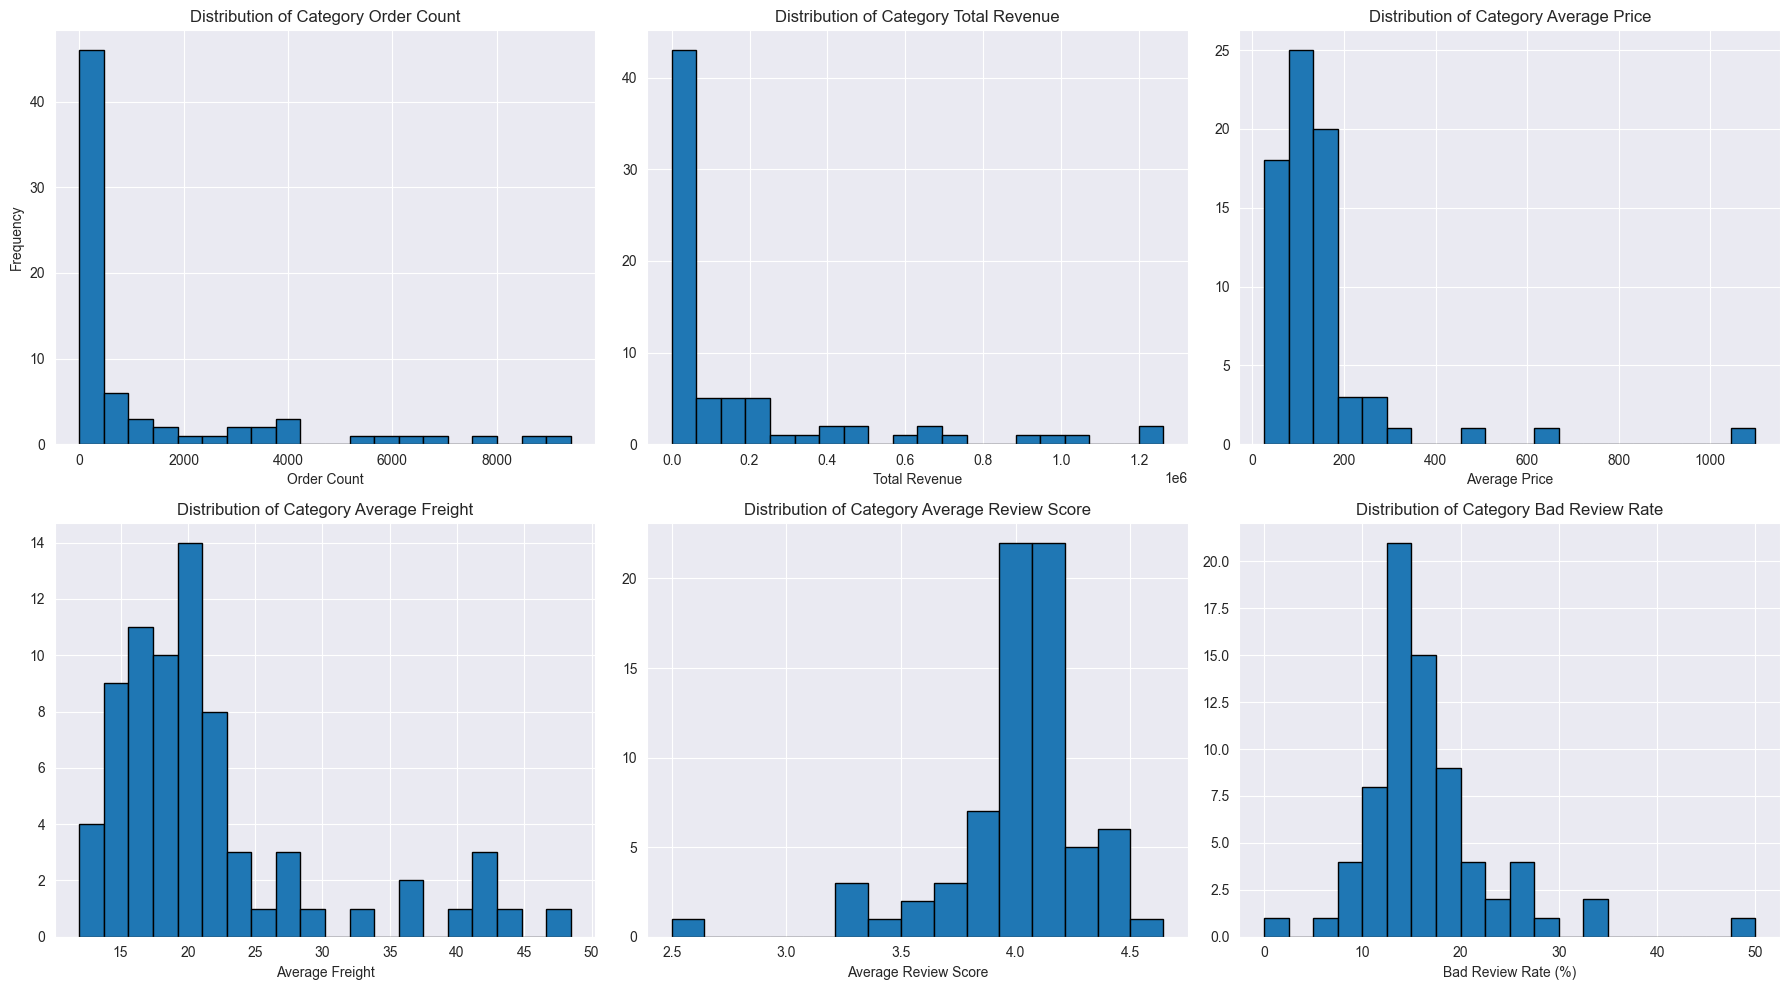

In [12]:
# plot the distribution of major category-level metrics
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# order count
axes[0, 0].hist(df_category["order_count"], bins=20, edgecolor="black")
axes[0, 0].set_title("Distribution of Category Order Count")
axes[0, 0].set_xlabel("Order Count")
axes[0, 0].set_ylabel("Frequency")

# total revenue
axes[0, 1].hist(df_category["total_revenue"], bins=20, edgecolor="black")
axes[0, 1].set_title("Distribution of Category Total Revenue")
axes[0, 1].set_xlabel("Total Revenue")

# average price
axes[0, 2].hist(df_category["avg_price"], bins=20, edgecolor="black")
axes[0, 2].set_title("Distribution of Category Average Price")
axes[0, 2].set_xlabel("Average Price")

# average freight
axes[1, 0].hist(df_category["avg_freight"], bins=20, edgecolor="black")
axes[1, 0].set_title("Distribution of Category Average Freight")
axes[1, 0].set_xlabel("Average Freight")

# average review score
axes[1, 1].hist(df_category["avg_review_score"], bins=15, edgecolor="black")
axes[1, 1].set_title("Distribution of Category Average Review Score")
axes[1, 1].set_xlabel("Average Review Score")

# bad review rate
axes[1, 2].hist(df_category["bad_review_rate"], bins=20, edgecolor="black")
axes[1, 2].set_title("Distribution of Category Bad Review Rate")
axes[1, 2].set_xlabel("Bad Review Rate (%)")

plt.tight_layout()
plt.show()

### Category-level Numerical Distribution Analysis
The distribution plots show that category performance is highly uneven across product categories. Both `order_count` and `total_revenue` are strongly right-skewed, which means a small number of categories contribute a disproportionately large share of total sales and orders. By contrast, `avg_review_score` is much more concentrated, with most categories clustered around 4.0, suggesting that customer satisfaction is relatively stable across categories. `avg_price`, `avg_freight`, and `bad_review_rate` also show noticeable variation, indicating that categories differ not only in sales scale but also in pricing structure, logistics burden, and review risk.

In [13]:
# summary statistics for key category-level variables

summary_stats = df_category[
    [
        "order_count",
        "customer_count",
        "total_revenue",
        "total_gmv",
        "avg_price",
        "avg_freight",
        "avg_review_score",
        "bad_review_rate",
        "avg_comment_len",
        "repeat_rate",
        "category_lifetime_days",
    ]
].describe().T

summary_stats

,count,mean,std,min,25%,50%,75%,max
order_count,73.0,1342.726027,2252.345988,2.000000,75.000000,244.000000,1273.000000,9.417000e+03
customer_count,73.0,1342.726027,2252.345988,2.000000,75.000000,244.000000,1273.000000,9.417000e+03
total_revenue,73.0,184193.989726,301910.559304,283.290000,7528.410000,46328.370000,191498.880000,1.261035e+06
total_gmv,73.0,214750.303288,349566.278958,324.510000,8754.610000,50193.570000,210137.370000,1.444124e+06
avg_price,73.0,146.695252,146.105578,25.342333,81.801667,114.949474,154.407282,1.098341e+03
avg_freight,73.0,21.620984,8.198948,11.938750,16.255090,19.324810,22.724680,4.845468e+01
avg_review_score,73.0,4.019816,0.313812,2.500000,3.936500,4.056200,4.170000,4.642900e+00
bad_review_rate,73.0,16.405375,6.885987,0.000000,12.978280,15.068490,18.000000,5.000000e+01
avg_comment_len,73.0,30.527571,13.073281,4.125000,26.740700,29.305600,32.806700,1.150000e+02
repeat_rate,73.0,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000e+00


### summary statistics analysis
The descriptive statistics further confirm that category performance is highly dispersed. For example, the median `order_count` is only 244, while the mean is much higher at about 1342.73, showing that a few very large categories pull the average upward. A similar pattern appears in `total_revenue`, where the mean is far above the median, again indicating strong concentration among top-performing categories. In contrast, `avg_review_score` has a narrow spread around 4.02, suggesting that satisfaction differences exist but are much smaller than sales differences. It is also worth noting that `repeat_rate` is constant at 1.0 for all categories, which means this variable has no variation in the current aggregated table and may have limited analytical value in later sections.

### 2.3 Outlier Detection for Key Category Metrics
Because category-level business indicators may be dominated by a few extremely large or small categories, it is useful to check whether outliers are present. Outlier detection helps distinguish between normal variation and unusually extreme category behaviour. In this project, the IQR rule is used as a simple and interpretable method for identifying extreme values.

In [14]:
# function to detect outliers using IQR
def detect_outliers_iqr(df, columns):
    results = []

    for col in columns:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1

        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr

        outlier_mask = (df[col] < lower_bound) | (df[col] > upper_bound)

        results.append({
            "variable": col,
            "q1": q1,
            "q3": q3,
            "iqr": iqr,
            "lower_bound": lower_bound,
            "upper_bound": upper_bound,
            "outlier_count": outlier_mask.sum(),
            "outlier_pct": outlier_mask.mean() * 100
        })

    return pd.DataFrame(results)

key_vars = ["order_count", "total_revenue", "avg_price", "avg_freight", "bad_review_rate"]

outlier_summary = detect_outliers_iqr(df_category, key_vars)
outlier_summary

,variable,q1,q3,iqr,lower_bound,upper_bound,outlier_count,outlier_pct
0,order_count,75.000000,1273.000000,1198.000000,-1722.000000,3070.000000,13,17.808219
1,total_revenue,7528.410000,191498.880000,183970.470000,-268427.295000,467454.585000,11,15.068493
2,avg_price,81.801667,154.407282,72.605615,-27.106756,263.315705,7,9.589041
3,avg_freight,16.255090,22.724680,6.469590,6.550705,32.429065,9,12.328767
4,bad_review_rate,12.978280,18.000000,5.021720,5.445700,25.532580,9,12.328767


### IQR analysis
The IQR-based outlier summary shows that extreme values are most visible in `order_count` and `total_revenue`, where 13 and 11 categories are flagged as outliers respectively. This suggests that category sales structure is strongly dominated by a relatively small group of very large categories. Outliers are also present in `avg_price`, `avg_freight`, and `bad_review_rate`, although to a lesser extent, indicating that some categories are unusually expensive, costly to deliver, or associated with unusually high negative feedback. These results suggest that outliers in this project are not random noise, but potentially meaningful business signals.

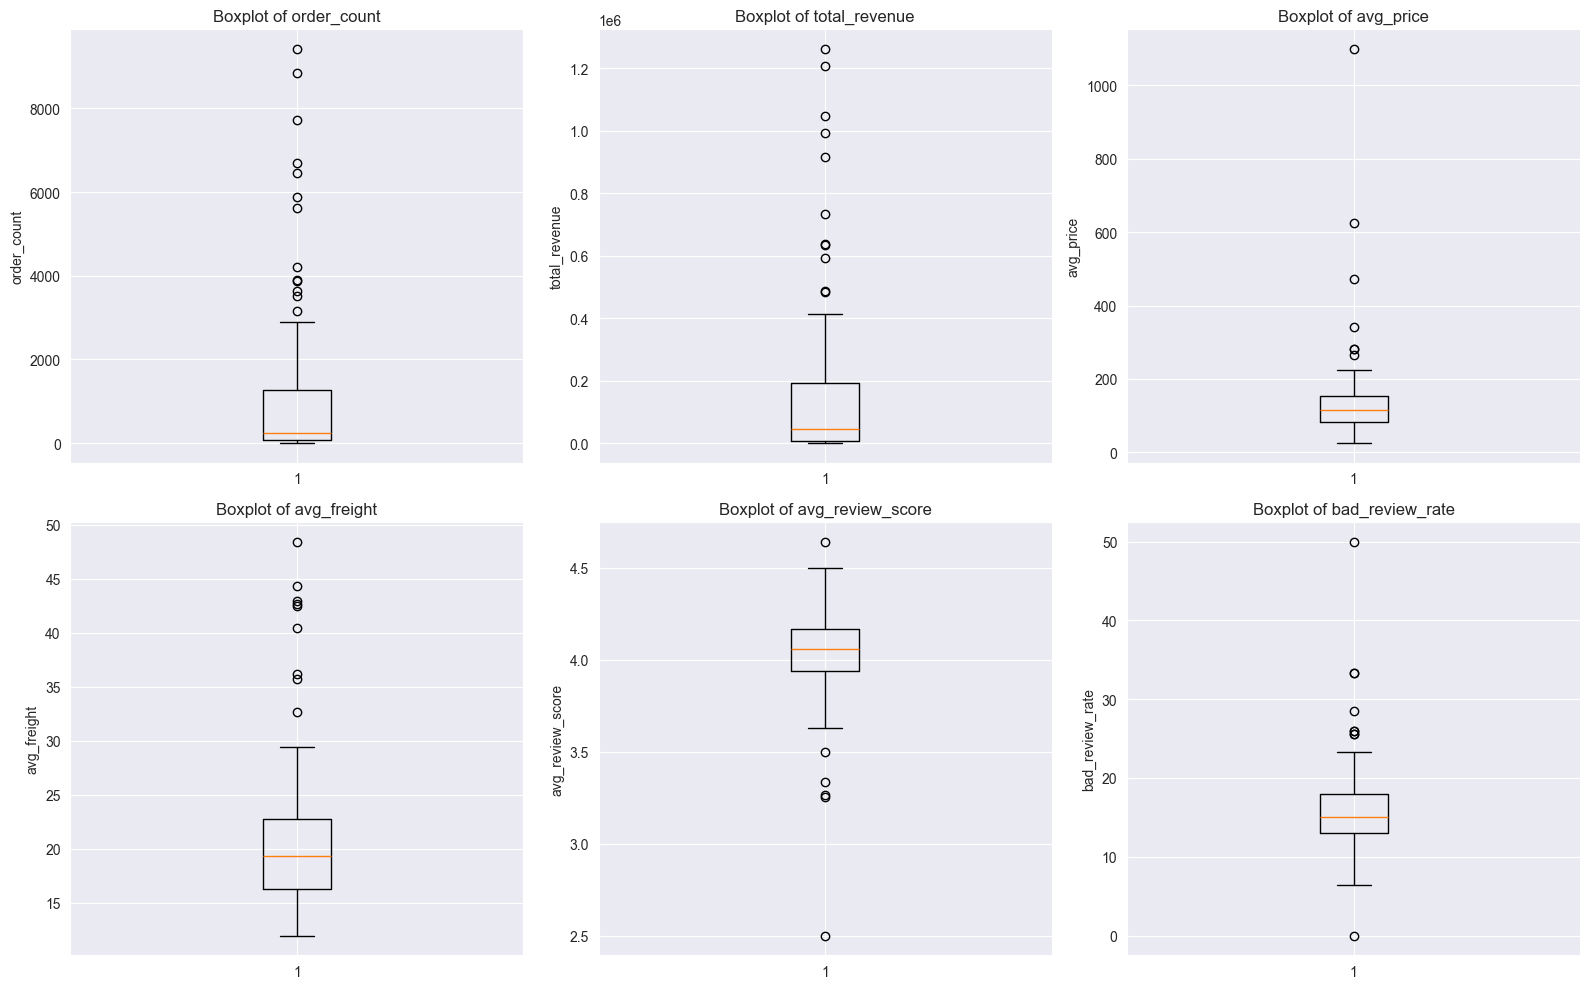

In [15]:
# boxplots for selected category-level variables

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

plot_vars = ["order_count", "total_revenue", "avg_price", "avg_freight", "avg_review_score", "bad_review_rate"]

for i, col in enumerate(plot_vars):
    axes[i].boxplot(df_category[col].dropna(), vert=True)
    axes[i].set_title(f"Boxplot of {col}")
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()

### boxplots for selected category-level variables analysis
The boxplots provide a visual confirmation of the outlier patterns identified above. `order_count` and `total_revenue` show long upper tails and many points above the upper whisker, which indicates that several categories perform far above the typical range. `avg_price` and `avg_freight` also contain a number of high-end outliers, suggesting that some product groups operate in clearly different price and logistics bands. Meanwhile, `avg_review_score` is much more tightly distributed, although a few low-score categories stand out and many deserve closer business attention. The `bad_review_rate` boxplot also reveals several high-risk categories with unusually poor review outcomes.

In [16]:
# identify the specific categories flagged as outliers for selected variables

for col in ["order_count", "total_revenue", "avg_price", "bad_review_rate"]:
    q1 = df_category[col].quantile(0.25)
    q3 = df_category[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outliers = df_category[
        (df_category[col] < lower_bound) | (df_category[col] > upper_bound)
    ][["category", col]].sort_values(col, ascending=False)

    print(f"\nOutlier categories for {col}:")
    display(outliers)


Outlier categories for order_count:


,category,order_count
13,cama_mesa_banho,9417
11,beleza_saude,8836
32,esporte_lazer,7720
44,informatica_acessorios,6689
54,moveis_decoracao,6449
72,utilidades_domesticas,5884
66,relogios_presentes,5624
70,telefonia,4199
8,automotivo,3897
12,brinquedos,3886



Outlier categories for total_revenue:


,category,total_revenue
11,beleza_saude,1261034.70
66,relogios_presentes,1206047.43
13,cama_mesa_banho,1045462.93
32,esporte_lazer,991175.20
44,informatica_acessorios,916137.43
54,moveis_decoracao,733077.86
26,cool_stuff,636254.61
72,utilidades_domesticas,632981.59
8,automotivo,593227.66
40,ferramentas_jardim,486400.55



Outlier categories for avg_price:


,category,avg_price
61,pcs,1098.340542
64,portateis_casa_forno_e_cafe,624.285658
29,eletrodomesticos_2,473.272458
0,agro_industria_e_comercio,342.124858
45,instrumentos_musicais,281.616000
31,eletroportateis,280.284112
65,portateis_cozinha_e_preparadores_de_alimentos,264.568667



Outlier categories for bad_review_rate:


,category,bad_review_rate
67,seguros_e_servicos,50.00000
65,portateis_cozinha_e_preparadores_de_alimentos,33.33333
60,pc_gamer,33.33333
38,fashion_roupa_masculina,28.46154
15,casa_conforto_2,25.92593
55,moveis_escritorio,25.92372
42,fraldas_higiene,25.64103
71,telefonia_fixa,25.57252
17,cds_dvds_musicais,0.00000


### The category-level outlier tables analysis
The category-level outlier tables show that the extreme observations are concentrated in a few specific product groups. In terms of sales scale, categories such as `cama_mesa_banho`, `beleza_saude`, `esporte_lazer`, `informatica_acessorios`, and `moveis_decoracao` stand out as major outliers in both `order_count` and `total_revenue`, which suggests that they function as core commercial categories in the platform. In terms of pricing, categories such as `pcs`, `portateis_casa_forno_e_cafe`, and `eletrodomesticos_2` have exceptionally high average prices, indicating that they belong to premium or specialised product segments rather than mass-market categories. In contrast, categories such as `seguros_e_servicos`, `pc_gamer`, and `fashion_roupa_masculina` appear as outliers in `bad_review_rate`, suggesting potential issues in customer expectation, product quality, or service performance. Overall, these outlier categories should not be treated as data errors; instead, they represent strategically important groups that deserve closer examination in the later ranking and business insight sections.

### 2.4 Preliminary Revenue Concentration Check
Before moving to formal ranking analysis, it is useful to briefly examine how concentrated category revenue is. This provides an early indication of whether the category structure is broad-based or heavily dependent on a small number of categories.

In [17]:
# calculate category revenue share
df_concentration = df_category[["category", "total_revenue"]].copy()
df_concentration["revenue_share_pct"] = (
    df_concentration["total_revenue"] / df_concentration["total_revenue"].sum() * 100
)

df_concentration = df_concentration.sort_values("total_revenue", ascending=False)

print("Top 10 categories by revenue share:")
display(df_concentration.head(10))

print(f"Revenue share of top 5 categories: {df_concentration.head(5)['revenue_share_pct'].sum():.2f}%")
print(f"Revenue share of top 10 categories: {df_concentration.head(10)['revenue_share_pct'].sum():.2f}%")

Top 10 categories by revenue share:


,category,total_revenue,revenue_share_pct
11,beleza_saude,1261034.70,9.378399
66,relogios_presentes,1206047.43,8.969455
13,cama_mesa_banho,1045462.93,7.775178
32,esporte_lazer,991175.20,7.371436
44,informatica_acessorios,916137.43,6.813375
54,moveis_decoracao,733077.86,5.451949
26,cool_stuff,636254.61,4.731868
72,utilidades_domesticas,632981.59,4.707526
8,automotivo,593227.66,4.411874
40,ferramentas_jardim,486400.55,3.617393


Revenue share of top 5 categories: 40.31%
Revenue share of top 10 categories: 63.23%


### Top 10 categories by revenue share analysis
The preliminary revenue concentration results show that category sales are highly concentrated among a small number of leading categories. `beleza_saude` ranks first, contributing about 9.38% of total revenue alone, followed by `relogios_presentes` at 8.97% and `cama_mesa_banho` at 7.78%. More importantly, the top 5 categories together account for 40.31% of total revenue, while the top 10 categories contribute 63.23%. This indicates that the platform’s category revenue structure is strongly dependent on a relatively limited set of core categories, which is an important business signal for later Pareto analysis and category strategy planning.

## 3. Category Ranking Analysis
Category ranking analysis aims to identify the best-performing and worst-performing product categories from multiple business perspectives. Instead of looking at only one metric, this chapter compares categories by revenue, order volume, customer satisfaction, and bad review rate. This helps distinguish categories that are commercially important from those that many require operational attention. Such ranking analysis also provides the basis for later Parato analysis and BCG-style strategic classification.

### 3.1 Top 10 Categories by Revenue
Revenue is one of the most direct indicators of categories business value. Analysing the top categories by total revenue helps identify which product groups contribute most strongly to platform income. These categories are commercially important because they often represent the main drives of gross merchandise performance and should therefore receive closer attention in later strategic analysis.

In [19]:
# rank categories by total revenue

top10_revenue = (
    df_category[["category", "total_revenue", "order_count", "avg_review_score"]]
    .sort_values("total_revenue", ascending=False)
    .head(10)
)

print("Top 10 categories by total revenue")
display(top10_revenue)

Top 10 categories by total revenue


,category,total_revenue,order_count,avg_review_score
11,beleza_saude,1261034.70,8836,4.1422
66,relogios_presentes,1206047.43,5624,4.0192
13,cama_mesa_banho,1045462.93,9417,3.9022
32,esporte_lazer,991175.20,7720,4.1087
44,informatica_acessorios,916137.43,6689,3.9364
54,moveis_decoracao,733077.86,6449,3.9114
26,cool_stuff,636254.61,3632,4.1480
72,utilidades_domesticas,632981.59,5884,4.0562
8,automotivo,593227.66,3897,4.0650
40,ferramentas_jardim,486400.55,3518,4.0435


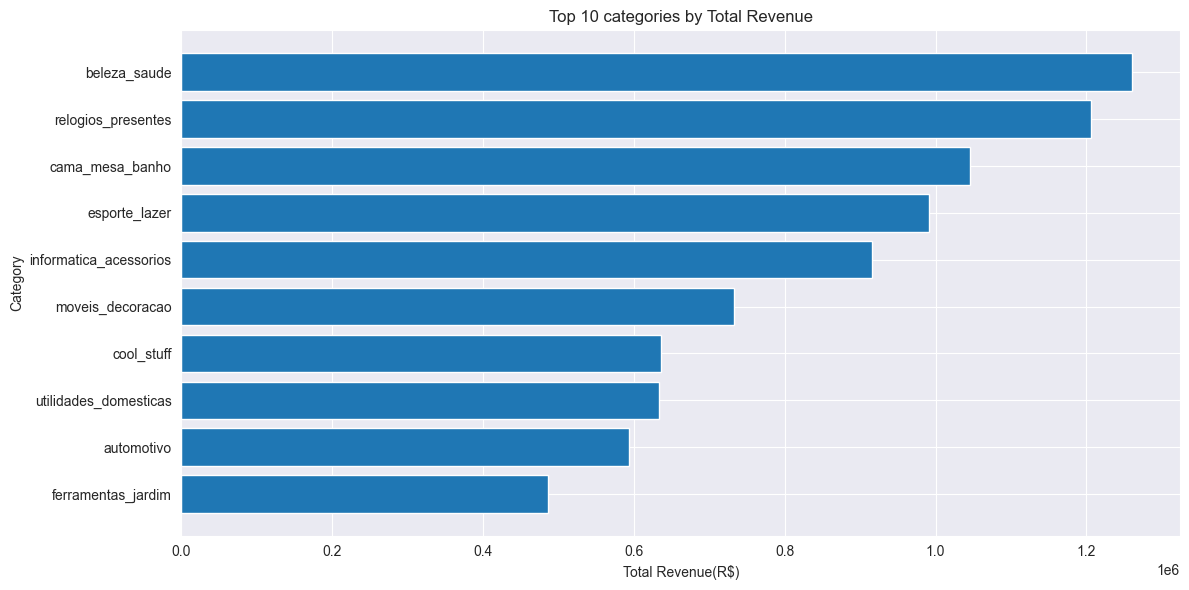

In [20]:
# visualise top 10 categories by total revenue

plt.figure(figsize=(12, 6))
plt.barh(top10_revenue["category"], top10_revenue["total_revenue"])
plt.xlabel("Total Revenue(R$)")
plt.ylabel("Category")
plt.title("Top 10 categories by Total Revenue")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [21]:
# add revenue share for easier interpretation

top10_revenue = top10_revenue.copy()
top10_revenue["revenue_share_pct"] = (
    top10_revenue["total_revenue"] / df_category["total_revenue"].sum() * 100
)

display(top10_revenue)

,category,total_revenue,order_count,avg_review_score,revenue_share_pct
11,beleza_saude,1261034.70,8836,4.1422,9.378399
66,relogios_presentes,1206047.43,5624,4.0192,8.969455
13,cama_mesa_banho,1045462.93,9417,3.9022,7.775178
32,esporte_lazer,991175.20,7720,4.1087,7.371436
44,informatica_acessorios,916137.43,6689,3.9364,6.813375
54,moveis_decoracao,733077.86,6449,3.9114,5.451949
26,cool_stuff,636254.61,3632,4.1480,4.731868
72,utilidades_domesticas,632981.59,5884,4.0562,4.707526
8,automotivo,593227.66,3897,4.0650,4.411874
40,ferramentas_jardim,486400.55,3518,4.0435,3.617393


### Top 10 Categories by Revenue analysis
The revenue ranking shows that a small group of categories contributes a large share of platform income. `beleza_saude`ranks first with total revenue of R$1,261,034.70, followed by `relogios_presents`((R$1,206,047.43) and `cama_mesa_banho`(R$1,045,462.93). Most of the top revenue categories also have high order volumes, although their average review scores are not always the highest. This suggests that strong commercial performance dose not necessarily mean the best customer satisfaction, so these core categories should be examined further from both sales and experience perspectives.